In [ ]:
from attacks import *
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, Subset
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import random
import time
import copy
import pickle
from collections import Counter
import scipy
import csv
import os
from util.densenet import*
from util.eval import compute_accuracy
import matplotlib.pyplot as plt
from opacus import PrivacyEngine
from opacus.validators import ModuleValidator
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from sklearn.metrics import precision_score
%matplotlib inline

In [3]:
model=densenet(num_classes=10,depth=100,growthRate=12,compressionRate=2,dropRate=0)
params = sum(p.numel() for p in model.parameters())
params

769162

In [4]:
import warnings
from sklearn.exceptions import ConvergenceWarning, FitFailedWarning

# Filter out ConvergenceWarning and FitFailedWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FitFailedWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [5]:
random.seed(1)
# prepare test data parts
transform_train = transforms.Compose([  
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

dataloader = datasets.CIFAR10
num_classes = 10
trainset = dataloader(root='./data', train=True, download=True, transform=transform_train)
testset = dataloader(root='./data', train=False, download=True, transform=transform_test)

X = []
Y = []
for item in trainset: 
    X.append( item[0].numpy() )
    Y.append( item[1]  )
for item in testset:
    X.append( item[0].numpy() )
    Y.append( item[1]  )
X = np.asarray(X)
Y = np.asarray(Y)

print("Loading data ..")

n_data = len(Y)
print('Total number of data points: ',n_data, flush=True)

n_train_data = len(trainset) 
n_val_data = len(testset)
n_test_data = n_val_data 

all_indices=pickle.load(open('./cifar10_shuffle.pkl','rb'))

# Sample train, val and test sets from  the whole data
train_inputs = X[all_indices[:n_train_data]]
train_labels=Y[all_indices[:n_train_data]]
test_inputs = X[all_indices[n_train_data:]]
test_labels = Y[all_indices[n_train_data:]]

# Create TensorDatasets
train_dataset = TensorDataset(torch.tensor(train_inputs, dtype=torch.float32), torch.tensor(train_labels, dtype=torch.int64))
test_dataset = TensorDataset(torch.tensor(test_inputs, dtype=torch.float32), torch.tensor(test_labels, dtype=torch.int64))

# Create DataLoader instances
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print('Trainset len %d | Testset len %d'% (n_train_data, n_test_data), flush=True)

Files already downloaded and verified
Files already downloaded and verified
Loading data ..
Total number of data points:  60000
Trainset len 50000 | Testset len 10000


In [51]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model=densenet(num_classes=num_classes,depth=100,growthRate=12,compressionRate=2,dropRate=0)
model=model.to(device)
# model = ModuleValidator.fix(model)
# ModuleValidator.validate(model, strict=False)
# optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
# criterion = nn.CrossEntropyLoss()
# privacy_engine = PrivacyEngine()
# model, optimizer, data_loader = privacy_engine.make_private(
#     module=model,
#     optimizer=optimizer,
#     data_loader=train_loader,
#     noise_multiplier=0.5,
#     max_grad_norm=1.0,
# ) 

checkpoint_dir='./checkpoints_regdrop/model_best_wd0.0005_drop0.2500.t7'
checkpoint = torch.load(checkpoint_dir)
for k in checkpoint.keys():
    if  'time' in k or 'eps' in k:
        print(k, ":", checkpoint[k])
model.load_state_dict(checkpoint['state_dict'])

logits_test, loss_test, test_labels, test_preds = compute_attack_components(model, test_loader)
logits_train, loss_train, train_labels, train_preds = compute_attack_components(model, train_loader)

train_acc, train_probs = compute_accuracy(logits_train, train_labels)
print('Train Acc:{:0.2f}%'.format(train_acc*100))
test_acc, test_probs = compute_accuracy(logits_test, test_labels)
print('Test Acc:{:0.2f}%'.format(test_acc*100))

attack_result = tf_attack(logits_train, logits_test, loss_train, loss_test, 
                      train_labels, test_labels)
auc = attack_result.get_result_with_max_auc().get_auc()
adv = attack_result.get_result_with_max_attacker_advantage().get_attacker_advantage()
print('AUC:{:0.2f}%'.format(100.0*auc))
print('Advantage:{:0.2f}%'.format(100.0*adv))
print('------------------------')

time : 3792.923230409622
Train Acc:99.85%
Test Acc:92.46%
AUC:56.34%
Advantage:15.53%
------------------------


In [52]:
#Our defense

# Define classes from training labels and initialize centroids
t0 = time.time()
classes = set(train_labels)
class_centroids = {c: None for c in classes}

defended_logits_train = copy.deepcopy(logits_train)
defended_logits_test = copy.deepcopy(logits_test)

# Calculate centroids for each class in training data
for c in class_centroids:
    idxs_c = np.where(train_labels == c)[0]
    logits_c = logits_train[idxs_c]
    centroid = np.mean(logits_c, axis=0)
    class_centroids[c] = centroid

# # Apply centroids to logits in both train and test predictions
# for c, centroid in class_centroids.items():
#     # Update train logits
#     idxs_c_train = np.where(train_preds == c)[0]
#     defended_logits_train[idxs_c_train] = centroid
    
#     # Update test logits
#     idxs_c_test = np.where(test_preds == c)[0]
#     defended_logits_test[idxs_c_test] = centroid


# Function to compute cosine similarity
def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)
    return dot_product / (norm1 * norm2)

# Apply cosine similarity and update logits in both train and test predictions
w = 0.1
for c, centroid in class_centroids.items():
    # Update train logits
    idxs_c_train = np.where(train_preds == c)[0]
    for idx in idxs_c_train:
        logit = logits_train[idx]
        cs = w * cosine_similarity(logit, centroid)
        defended_logits_train[idx] = cs * logit + (1 - cs) * centroid
    
    # Update test logits
    idxs_c_test = np.where(test_preds == c)[0]
    for idx in idxs_c_test:
        logit = logits_test[idx]
        cs = w * cosine_similarity(logit, centroid)
        defended_logits_test[idx] = cs * logit + (1 - cs) * centroid
    
print('Time:{}'.format(time.time() - t0))


# Compute and print defended accuracies
defended_train_acc = compute_accuracy(defended_logits_train, train_labels)[0] * 100
defended_test_acc = compute_accuracy(defended_logits_test, test_labels)[0] * 100
print(f'Defended train Acc: {defended_train_acc:.2f}%')
print(f'Defended test Acc: {defended_test_acc:.2f}%')

# Calculate defended losses
criterion = nn.CrossEntropyLoss(reduction='none')
defended_train_loss = criterion(torch.from_numpy(defended_logits_train), torch.from_numpy(train_labels))
defended_test_loss = criterion(torch.from_numpy(defended_logits_test), torch.from_numpy(test_labels))

# Perform attack evaluation
attack_result = tf_attack(
    defended_logits_train, defended_logits_test, defended_train_loss.detach().numpy(), 
    defended_test_loss.detach().numpy(), train_labels, test_labels
)
auc = attack_result.get_result_with_max_auc().get_auc()
adv = attack_result.get_result_with_max_attacker_advantage().get_attacker_advantage()

# Print attack metrics
print(f'AUC: {100.0 * auc:.2f}%')
print(f'Advantage: {100.0 * adv:.2f}%')
print('------------------------')


Time:0.467806339263916
Defended train Acc: 99.85%
Defended test Acc: 92.46%
AUC: 53.76%
Advantage: 7.73%
------------------------


In [49]:
# Be exceptionally careful.
# Numerically stable everything, as described in the paper.
predictions = logits_train - np.max(logits_train, axis=-1, keepdims=True)
predictions = np.array(np.exp(predictions), dtype=np.float64)
predictions = predictions / np.sum(predictions, axis=-1, keepdims=True)

labels = train_labels  # TODO generalize this

COUNT = predictions.shape[0]
y_true = predictions[np.arange(COUNT), labels[:COUNT]]

predictions[np.arange(COUNT), labels[:COUNT]] = 0
y_wrong = np.sum(predictions, axis=-1)

logit_train = np.log(y_true + 1e-45) - np.log(y_wrong + 1e-45) 
    
# Be exceptionally careful.
# Numerically stable everything, as described in the paper.
predictions = logits_test - np.max(logits_test, axis=-1, keepdims=True)
predictions = np.array(np.exp(predictions), dtype=np.float64)
predictions = predictions / np.sum(predictions, axis=-1, keepdims=True)

labels = test_labels  # TODO generalize this

COUNT = predictions.shape[0]
y_true = predictions[np.arange(COUNT), labels[:COUNT]]

predictions[np.arange(COUNT), labels[:COUNT]] = 0
y_wrong = np.sum(predictions, axis=-1)

logit_test = np.log(y_true + 1e-45) - np.log(y_wrong + 1e-45)

thresh = np.percentile(logit_test, 99)
tpr = (logit_train > thresh).mean()
fpr = (logit_test > thresh).mean()
print(tpr*100, fpr*100)

selected_train = np.where(logit_train >= thresh)[0]
selected_test = np.where(logit_test >= thresh)[0]

1.044 1.0


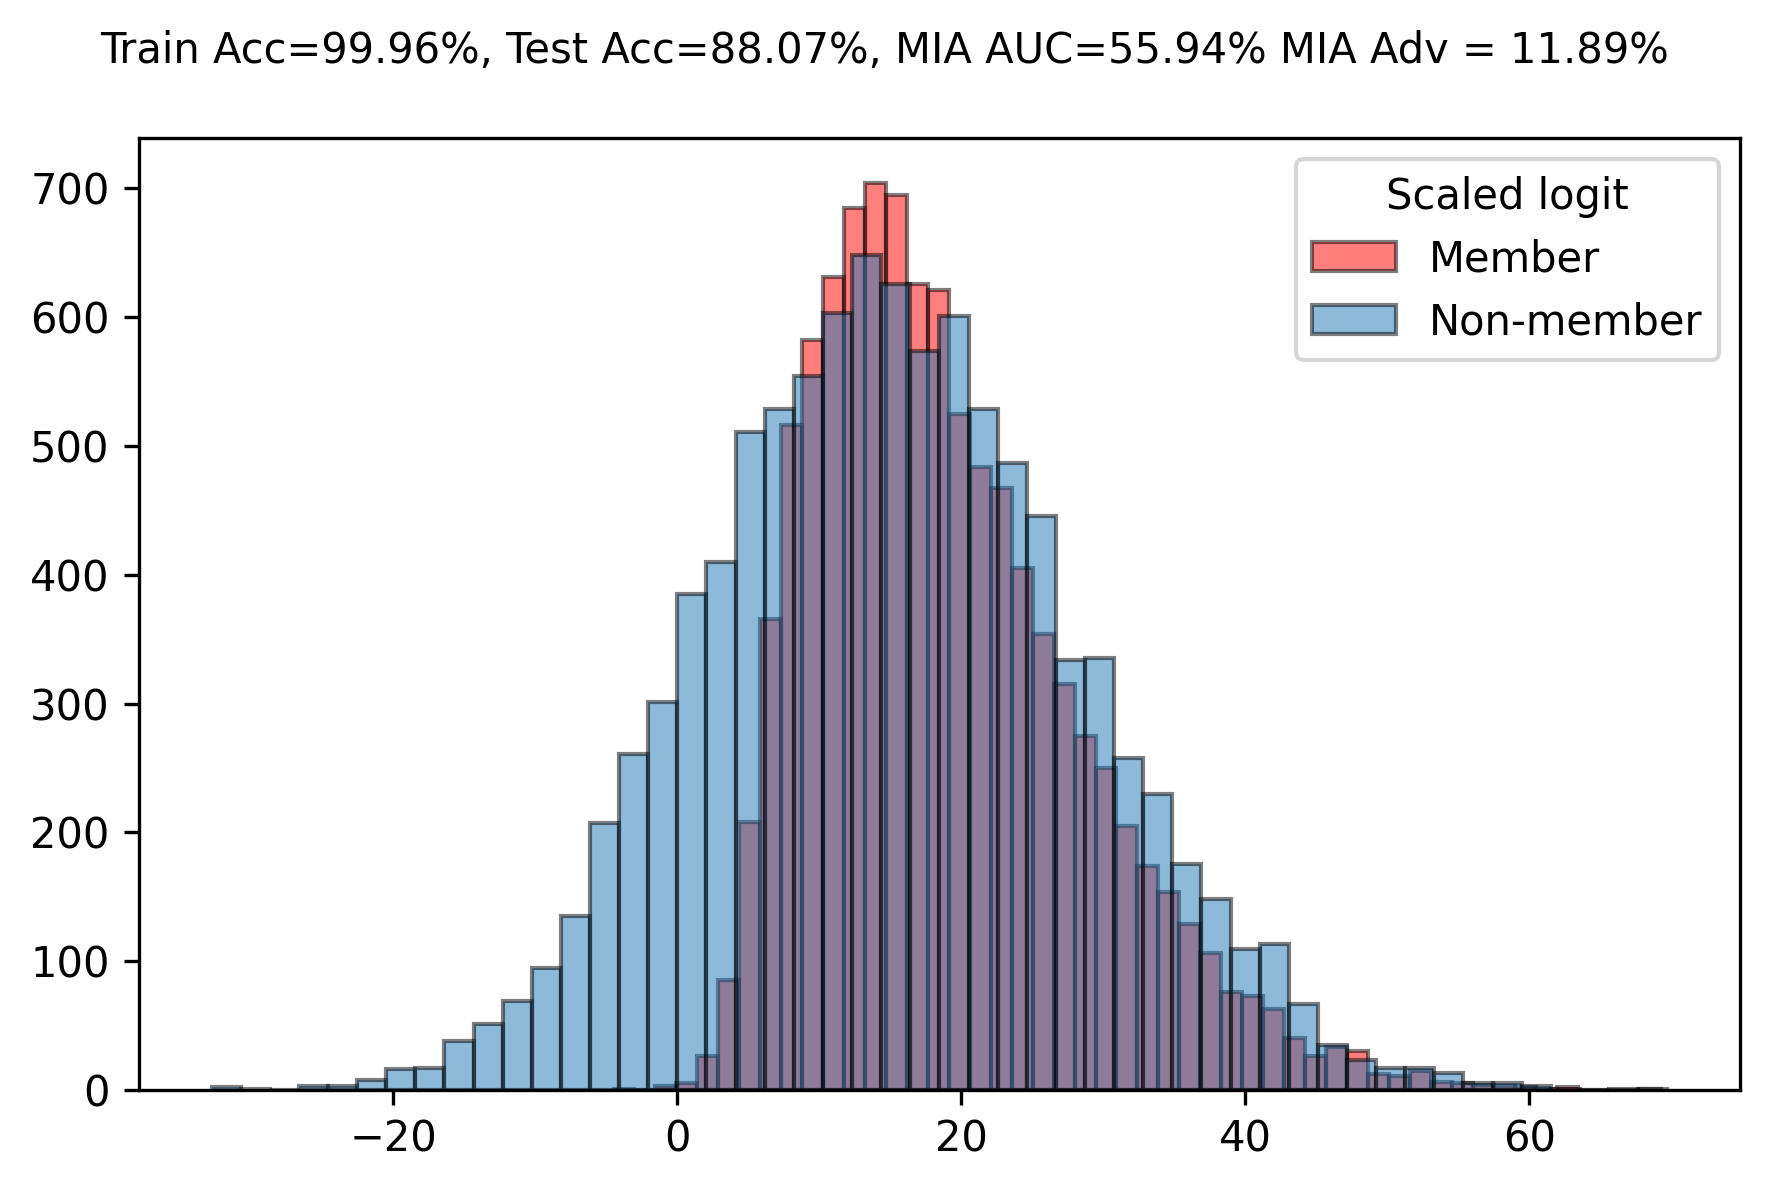

In [50]:
# Define figure size and dpi
figsize = (6, 4)
dpi = 300
legend_fontsize = 10

idxs = np.random.choice(len(train_labels), len(test_labels), replace = False)
# Create a figure with three subplots in one row
fig, axes = plt.subplots(1, 1, figsize=figsize, dpi=dpi)

fig.suptitle('Train Acc={:0.2f}%, Test Acc={:0.2f}%, MIA AUC={:0.2f}% MIA Adv = {:0.2f}%'.format(train_acc*100, test_acc*100, 
                                                                                        auc*100, adv*100), fontsize=legend_fontsize)


# Plot for scaled logit
axes.hist(logit_train[idxs], bins=50, alpha=0.5, label='Member', color='red', edgecolor='black')
axes.hist(logit_test, bins=50, alpha=0.5, label='Non-member', edgecolor='black')
axes.legend(loc='best', title='Scaled logit', fontsize=legend_fontsize, title_fontsize=legend_fontsize)


# Adjust layout
plt.tight_layout()
# # plt.savefig('figures/cifar10_densenet_logit_epoch60.png', bbox_inches='tight')
# Show the plot
plt.show()


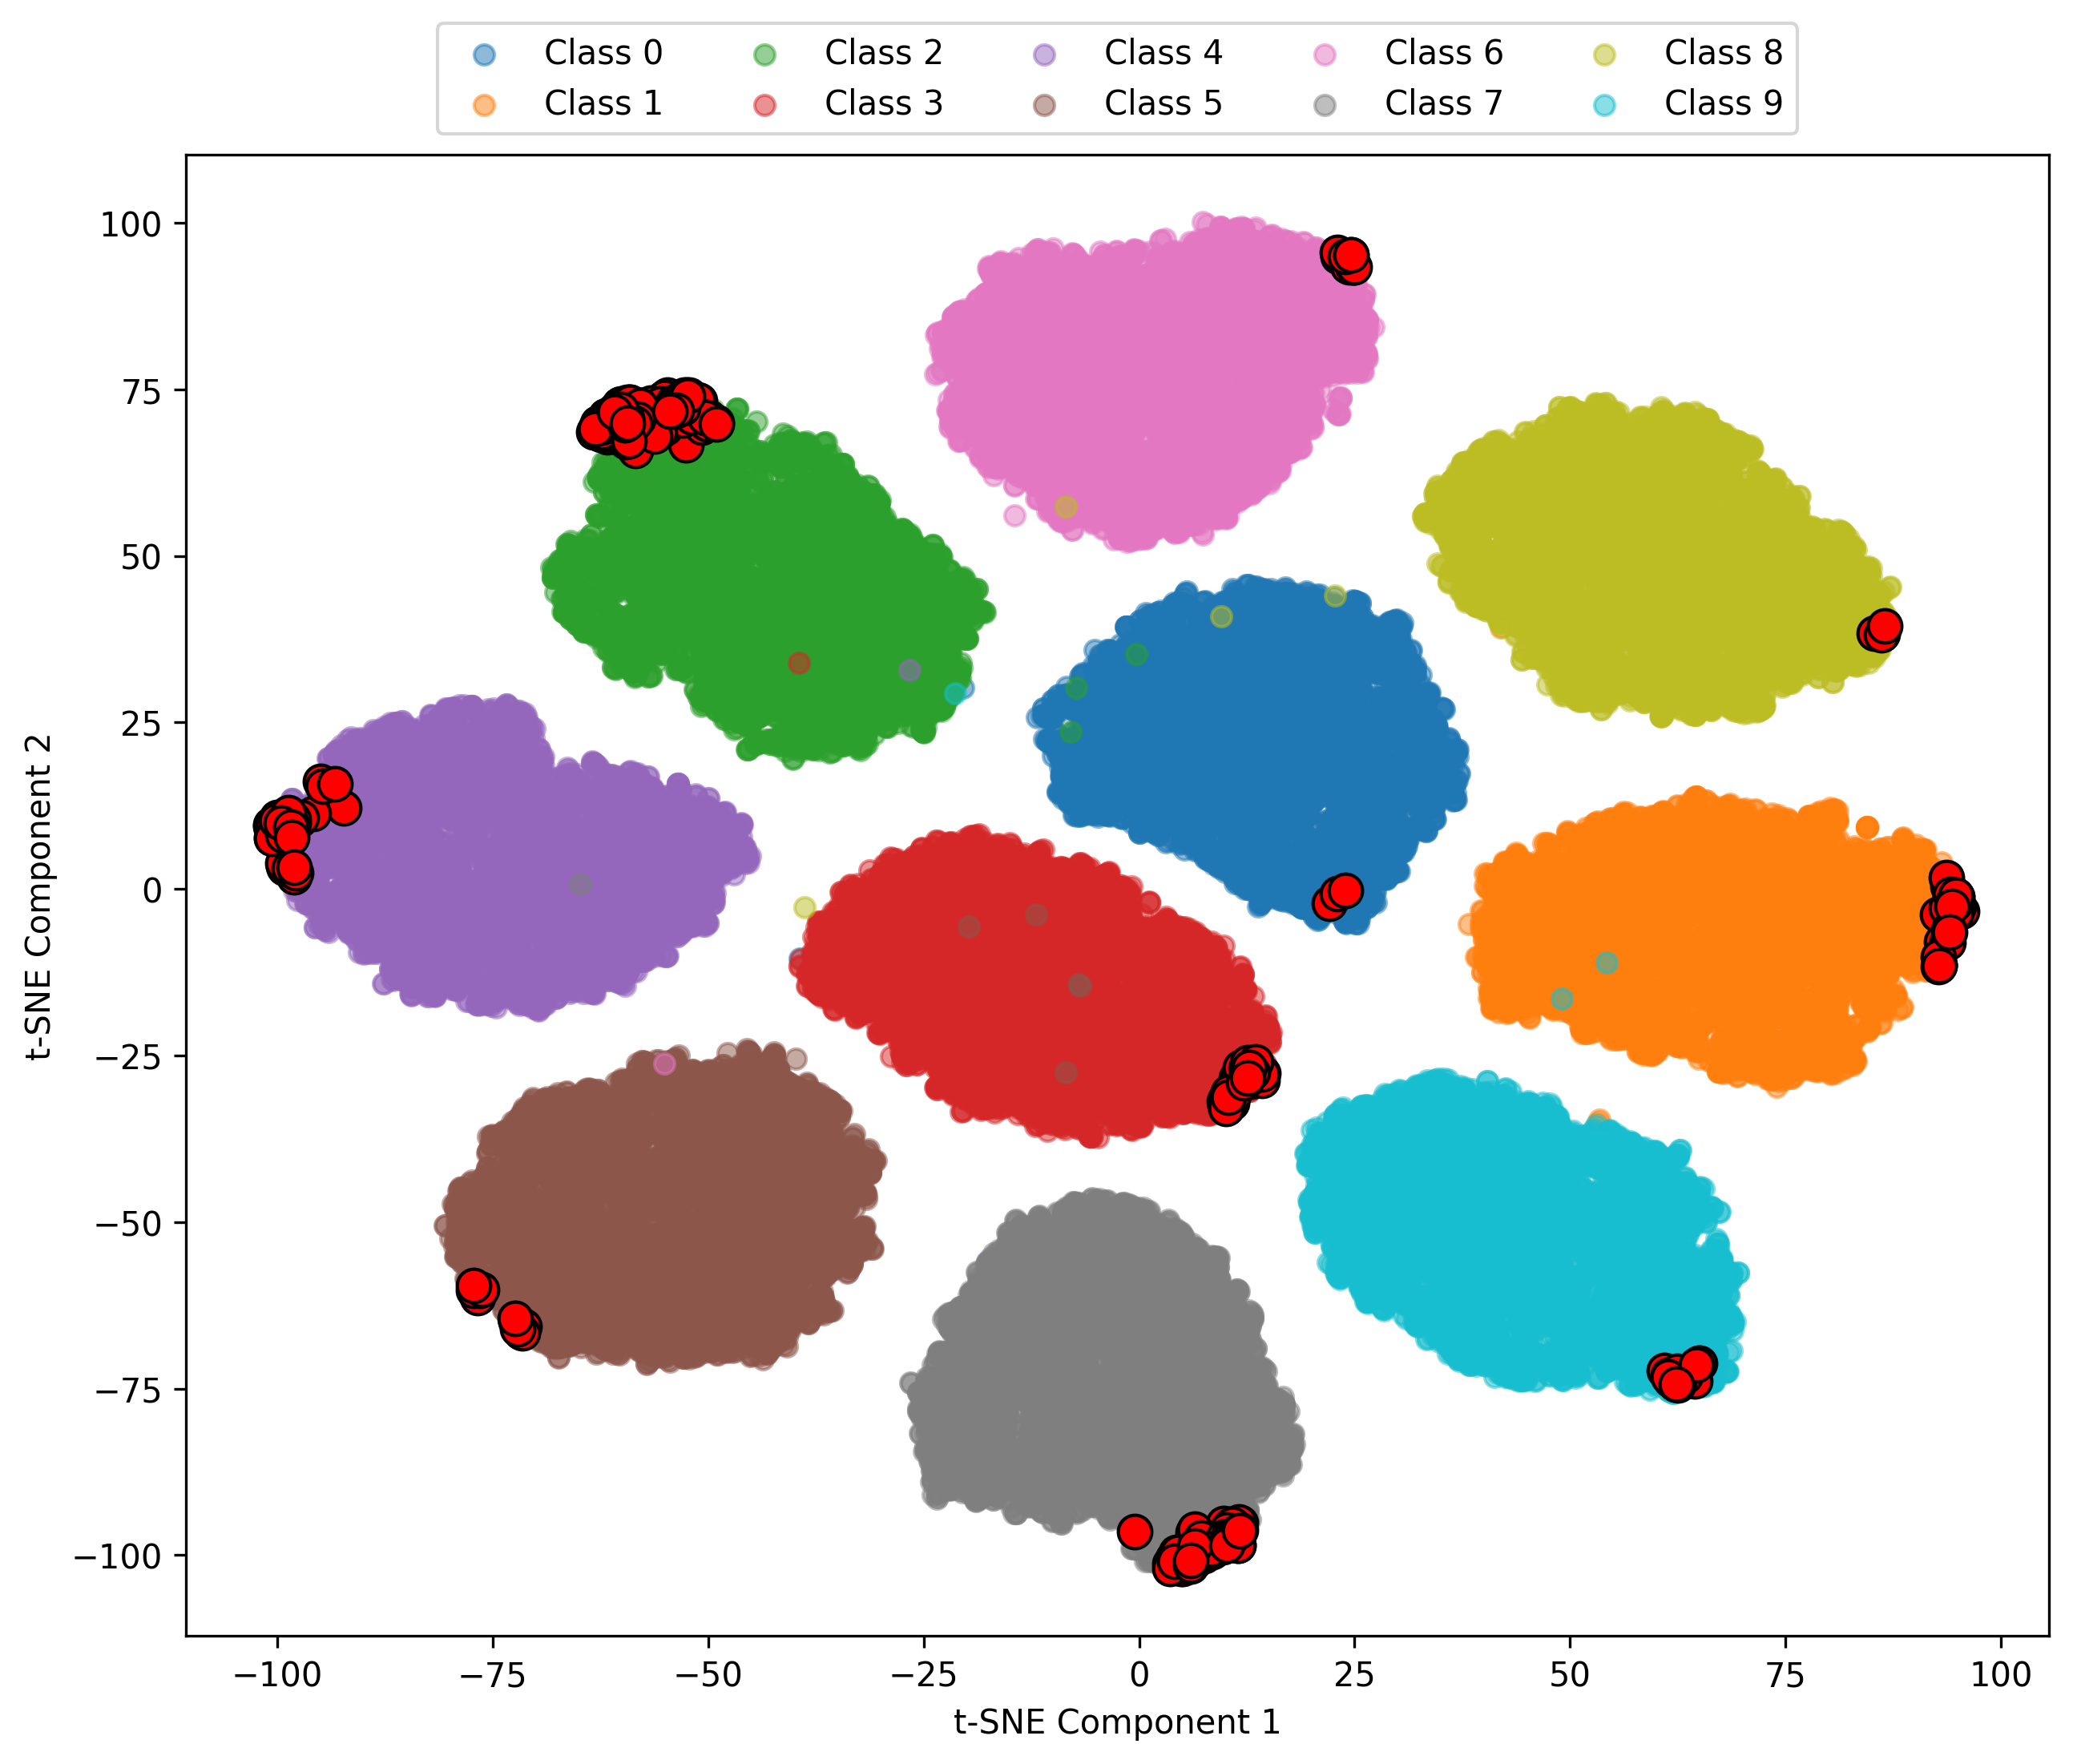

In [8]:
# from sklearn.manifold import TSNE

# figsize = (10, 8)
# dpi = 300

# # Perform t-SNE to reduce to 2 dimensions
# tsne = TSNE(n_components=2, random_state=42)
# ftrs_train_tsne = tsne.fit_transform(logits_train)

# unique_labels = np.unique(train_labels)

# fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=dpi)

# # Plot each class with a different color
# for label in unique_labels:
#     idxs = np.where(train_labels == label)[0]
#     ax.scatter(ftrs_train_tsne[idxs, 0], ftrs_train_tsne[idxs, 1], label=f'Class {label}', alpha=0.5)

#     # Highlight specific samples in red
#     intersect_idxs = np.intersect1d(idxs, selected_train)
#     ax.scatter(ftrs_train_tsne[intersect_idxs, 0], ftrs_train_tsne[intersect_idxs, 1], 
#                color='red', edgecolor='black', s=100)

# ax.set_xlabel('t-SNE Component 1')
# ax.set_ylabel('t-SNE Component 2')
# ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=5)
# plt.savefig('figures/tsne_logits_cifar10_densenet_1perfpr.png', dpi = 300)
# plt.show()

In [6]:
model.fc = nn.Identity()

ftrs = []
for inputs, targets in train_loader:
    inputs, targets = inputs.to(device), targets.to(device)
    ftr = model(inputs)  # Assuming 'features' was meant to be 'inputs'
    ftrs.append(ftr.detach().cpu())

ftrs = torch.cat(ftrs).numpy()

07/19/2024 23:03:55:WARNING:Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


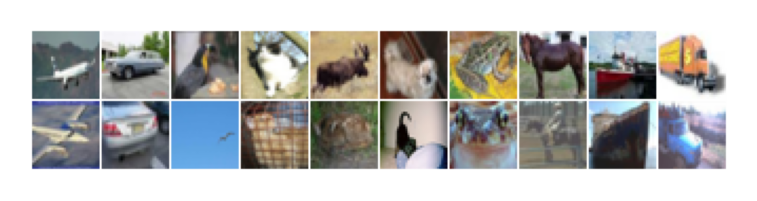

In [22]:
import torchvision
from torch.utils.data import Subset
from scipy.spatial.distance import cosine
import copy

# Define the inverse normalization class
class InverseNormalize:
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        for t, m, s in zip(tensor, self.mean, self.std):
            t.mul_(s).add_(m)
        return tensor
    
# Function to show an image
def imshow(img, title=''):
    img = inv_normalize(img)  # inverse normalization
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')  # Hide axes
    plt.title(title)
    plt.savefig('figures/cifar10_outlier_images.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    

unique_labels = np.unique(train_labels)
closest = [] 
farthest = []
targets_closest = []
targets_farthest = []
# Plot each class with a different color
for label in unique_labels:
    idxs = np.where(train_labels == label)[0]
    intersect_idxs = np.intersect1d(idxs, selected_train)
    ftr_cluster = ftrs[idxs]
    input_cluster = Subset(train_dataset, idxs)
    cl = ftr_cluster.mean(axis = 0)
    dist = np.array([cosine(ftr, cl) for ftr in ftr_cluster])
    closest.append(input_cluster[dist.argmin()][0])
    farthest.append(input_cluster[dist.argmax()][0])
    targets_closest.append(input_cluster[dist.argmin()][1])
    targets_farthest.append(input_cluster[dist.argmax()][1])

# Define the inverse normalization transform
inv_normalize = InverseNormalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])

figsize = (3, 2)
dpi = 300
fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=dpi)
imshow(torchvision.utils.make_grid(copy.deepcopy(closest+farthest), nrow=10, padding=1, pad_value=10), title = '')


In [8]:
checkpoint_dir='./checkpoints_regdrop/model_epoch100_wd0.0005_drop0.2500.t7'
checkpoint = torch.load(checkpoint_dir)
model=densenet(num_classes=num_classes,depth=100,growthRate=12,compressionRate=2,dropRate=0)
model=model.to(device)
model.load_state_dict(checkpoint['state_dict'])

<All keys matched successfully>

07/19/2024 23:07:25:WARNING:Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


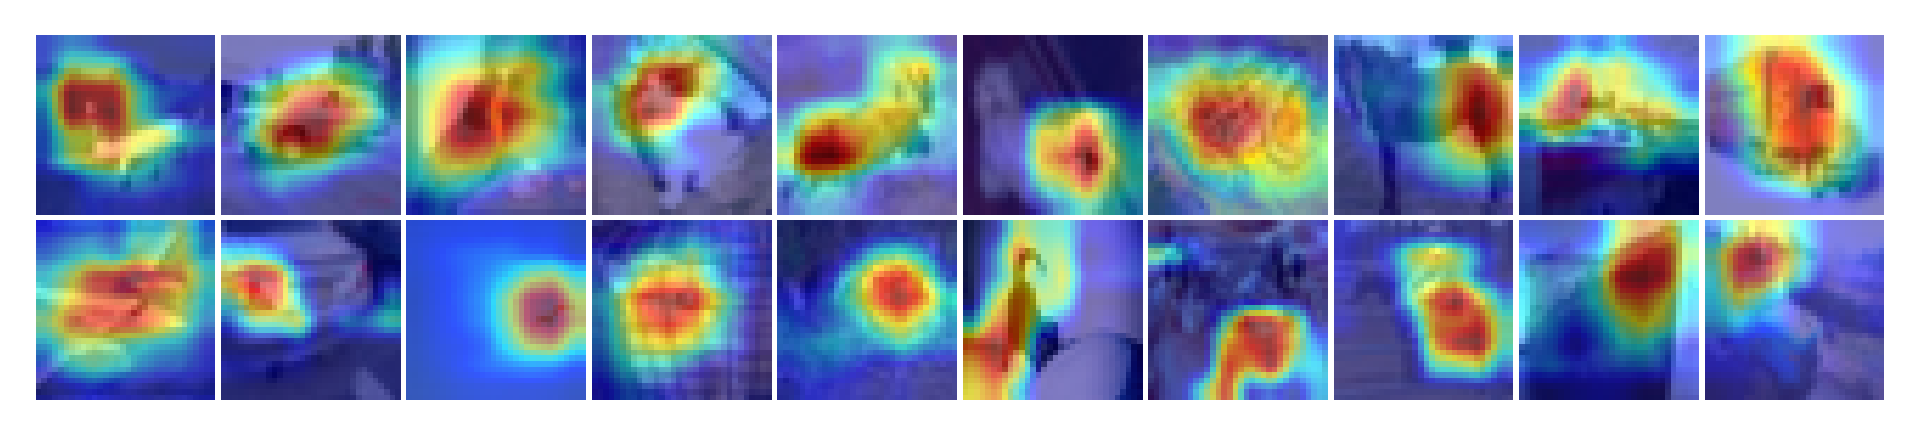

In [29]:
# Function to show an image
def imshow(img, title=''):
#     img = inv_normalize(img)  # inverse normalization
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')  # Hide axes
    plt.title(title)
    plt.savefig('figures/cifar10_outlier_gradcam.png', dpi=300, bbox_inches='tight')
    plt.show()
    

target_layers = [model.dense3[-1].conv2]  # Specify the target layer for Grad-CAM

# Visualize and save closest and farthest images with Grad-CAM overlays
def generate_gradcam_images(images, targets, model, target_layers):
    cam = GradCAM(model=model, target_layers=target_layers)
    cam_images = []
    
    for image, target in zip(images, targets):
        img_tensor = image.unsqueeze(0).to(device)
        grayscale_cam = cam(input_tensor=img_tensor, targets=[ClassifierOutputTarget(target)])
        grayscale_cam = grayscale_cam[0, :]
        
        img_np = np.transpose(image.numpy(), (1, 2, 0))
        img_np = inv_normalize(image).numpy().transpose(1, 2, 0)
        cam_img = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)
        
        cam_images.append(transforms.ToTensor()(cam_img))
    
    return cam_images, grayscale_cam

# Generate Grad-CAM images for closest and farthest samples
closest_cam_images, grayscale_cam1 = generate_gradcam_images(copy.deepcopy(closest), targets_closest, model, target_layers)
farthest_cam_images, grayscale_cam2 = generate_gradcam_images(copy.deepcopy(farthest), targets_farthest, model, target_layers)

# Combine the closest and farthest images
combined_images = closest_cam_images + farthest_cam_images

# Display the combined images in a grid
figsize = (8, 6)
dpi = 300
fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=dpi)
imshow(torchvision.utils.make_grid(copy.deepcopy(combined_images), nrow=10, padding=1, pad_value=10), title='')

In [ ]:
from sklearn.manifold import TSNE

figsize = (10, 8)
dpi = 300

# Perform t-SNE to reduce to 2 dimensions
tsne = TSNE(n_components=2, random_state=42)
ftrs_train_tsne = tsne.fit_transform(ftrs)

unique_labels = np.unique(train_labels)

fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=dpi)

# Plot each class with a different color
for label in unique_labels:
    idxs = np.where(train_labels == label)[0]
    ax.scatter(ftrs_train_tsne[idxs, 0], ftrs_train_tsne[idxs, 1], label=f'Class {label}', alpha=0.5)

    # Highlight specific samples in red
    intersect_idxs = np.intersect1d(idxs, selected_train)
    ax.scatter(ftrs_train_tsne[intersect_idxs, 0], ftrs_train_tsne[intersect_idxs, 1], 
               color='red', edgecolor='black', s=100)

ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=5)
plt.savefig('figures/tsne_ftrs_cifar10_densenet_0.5perfpr.png', dpi = 300)
plt.show()

In [4]:
# # Define figure size and dpi
# figsize = (16, 4)
# dpi = 300
# legend_fontsize = 10

# # Create a figure with three subplots in one row
# fig, axes = plt.subplots(1, 3, figsize=figsize, dpi=dpi)

# fig.suptitle('Test Acc={:0.2f}%, MIA AUC={:0.2f}% MIA Adv = {:0.2f}%'.format(test_acc*100, auc*100, adv*100), fontsize=16)

# # Plot for loss
# idxs = np.random.choice(len(train_labels), len(test_labels), replace = False)
# axes[0].hist(loss_train[idxs], bins=50, alpha=0.5, label='Member', color='red', edgecolor='black')
# axes[0].hist(loss_test, bins=50, alpha=0.5, label='Non-member', edgecolor='black')
# axes[0].legend(loc='best', title='Loss', fontsize=legend_fontsize, title_fontsize=legend_fontsize)


# # Plot for confidence
# axes[1].hist(train_probs[idxs].max(axis=-1), bins=50, alpha=0.5, label='Member', color='red', edgecolor='black')
# axes[1].hist(test_probs.max(axis=-1), bins=50, alpha=0.5, label='Non-member', edgecolor='black')
# axes[1].legend(loc='best', title='Confidence', fontsize=legend_fontsize, title_fontsize=legend_fontsize)


# # Plot for scaled logit
# axes[2].hist(logit_train[idxs], bins=50, alpha=0.5, label='Member', color='red', edgecolor='black')
# axes[2].hist(logit_test, bins=50, alpha=0.5, label='Non-member', edgecolor='black')

# axes[2].hist(logit_train[selected_train], bins=10, alpha=0.5, label='Member', color='orange', edgecolor='black')
# axes[2].hist(logit_test[selected_test], bins=10, alpha=0.5, label='Non-member', color='blue', edgecolor='black')

# axes[2].legend(loc='best', title='Scaled logit', fontsize=legend_fontsize, title_fontsize=legend_fontsize)


# # Adjust layout
# plt.tight_layout()
# # plt.savefig('figures/cifar10_densenet_lcl_epoch100.png', bbox_inches='tight')
# # Show the plot
# plt.show()


In [ ]:
# Our Defense

classes = set(train_labels)
class_cl = {c: None for c in classes}
for c in class_cl:
    print('Class:', c)
    idxs_c = np.where(train_labels == c)[0]
    logits_c = logits_train[idxs_c]
    centroid = np.mean(logits_c, axis = 0)
    class_cl[c] = centroid
    
for c in class_cl:
    centroid = class_cl[c]
    
    idxs_c = np.where(train_preds == c)[0]
    logits_train[idxs_c] = centroid
    
    idxs_c = np.where(test_preds == c)[0]
    logits_test[idxs_c] = centroid

print('Defended train Acc:{:0.2f}%'.format(compute_accuracy(logits_train, train_labels)*100))
print('Defended test Acc:{:0.2f}%'.format(compute_accuracy(logits_test, test_labels)*100))

criterion = nn.CrossEntropyLoss(reduction='none')
defended_train_loss = criterion(torch.from_numpy(logits_train), torch.from_numpy(train_labels))
defended_test_loss = criterion(torch.from_numpy(logits_test), torch.from_numpy(test_labels))

attack_result = tf_attack(logits_train, logits_test, defended_train_loss.numpy(), defended_test_loss.numpy(), 
                          train_labels, test_labels)
auc = attack_result.get_result_with_max_auc().get_auc()
adv = attack_result.get_result_with_max_attacker_advantage().get_attacker_advantage()

print('AUC:{:0.2f}%'.format(100.0*auc))
print('Advantage:{:0.2f}%'.format(100.0*adv))
print('------------------------')

In [ ]:

plt.figure(figsize=(10, 6))

# Plot histogram for loss_test
plt.hist(defended_test_loss, bins=30, alpha=0.5, label='Loss Test')

# Plot histogram for loss_train
plt.hist(defended_train_loss, bins=30, alpha=0.5, label='Loss Train')

# Add labels and title
plt.xlabel('Loss')
plt.ylabel('Frequency')
plt.title('Histograms of Loss Test and Loss Train')

# Add legend
plt.legend(loc='upper right')

# Show the plot
plt.show()
